In [8]:
import os
import re
import numpy as np
import tifffile
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

In [23]:
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

In [24]:
original_file = '/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/sequence-MT0.N1.HD-BP-Exp-as-list.tif'
main_folder = '/Users/laurabreimann/Desktop/figure_1/microtubule'

original_file_size = 41360118  # in bytes

In [25]:
def calculate_ssim(original_file, compressed_file):
    ssim_scores = []
    with tifffile.TiffFile(original_file) as tif_original, tifffile.TiffFile(compressed_file) as tif_compressed:
        for original_frame, compressed_frame in zip(tif_original.series[0].pages, tif_compressed.series[0].pages):
            original_image = original_frame.asarray()
            compressed_image = compressed_frame.asarray()
            score = ssim(original_image, compressed_image, data_range=compressed_image.max() - compressed_image.min())
            ssim_scores.append(score)
    return np.median(ssim_scores)

def get_total_size_of_files(folder_path, file_extensions):
    total_size = 0
    compressed_folder_path = os.path.join(folder_path, "compressed")
    for file in os.listdir(compressed_folder_path):
        if any(file.endswith(ext) for ext in file_extensions):
            total_size += os.path.getsize(os.path.join(compressed_folder_path, file))
    return total_size


In [30]:
results = {}
for folder in sorted(os.listdir(main_folder), key=natural_sort_key):
    folder_path = os.path.join(main_folder, folder)
    if os.path.isdir(folder_path):
        compressed_file = os.path.join(folder_path, 'sequence-MT0.N1.HD-BP.tif')
        median_ssim = calculate_ssim(original_file, compressed_file)
        total_file_size = get_total_size_of_files(folder_path, ['.mp4', '.npz', '.avi', '.mov', '.zst'])
        file_size_percentage = (total_file_size / original_file_size) * 100

        results[folder] = {
            'median_ssim': median_ssim,
            'file_size_percentage': file_size_percentage
        }

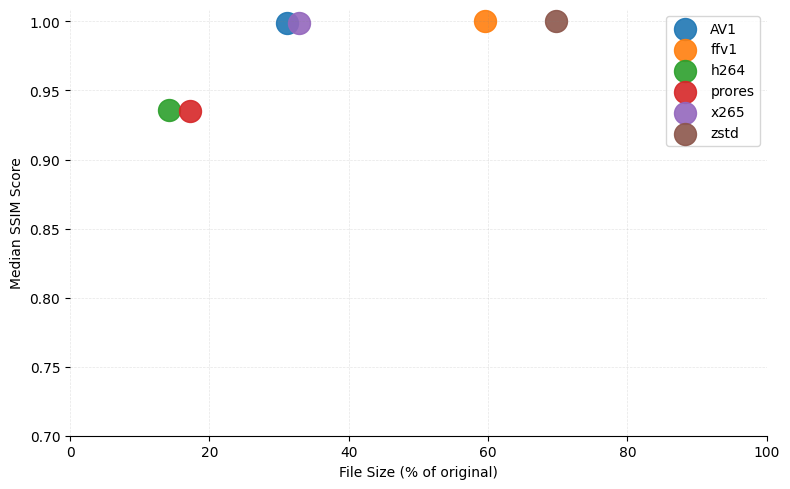

In [41]:

plt.figure(figsize=(8, 5))
for level, data in sorted(results.items()):
    # Simplify the label by removing "Compression" and "_level_0"
    simple_level = level.replace('Compression ', '').replace('_level_0', '')
    plt.scatter(data['file_size_percentage'], data['median_ssim'], label=simple_level, s=250, alpha=0.9)  # Increased marker size

plt.xlabel('File Size (% of original)')
plt.ylabel('Median SSIM Score')
#plt.title('SSIM vs. File Size Percentage')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.2)

# Set Y and X axis limits
plt.ylim(0.7, 1.009)
plt.xlim(0, 100)

plt.legend()
plt.tight_layout()

# Removing the top and right borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# Also, let's remove the left border
plt.gca().spines['left'].set_visible(False)

output_file = '/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/Figure1c_SSIM_filesize_240321.pdf'
plt.savefig(output_file, format='pdf')

plt.show()
plt.close()